## Assignment 4 Tree-based and Ensemble Models
# 670705001015 Naphat Utabuawong
Decision Tree, Random Forest, Gradient Boosting

---

# 1. Load data

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 100)

df = pd.read_csv('MBA.csv')
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [3]:
df['admission'].value_counts(dropna=False)

admission
NaN         5194
Admit        900
Waitlist     100
Name: count, dtype: int64

# 2. Explore and clean data (data wrangling)

The `admission` column has three states: `Admit`, `Waitlist`, and missing (no offer). Since the task
is to predict **admit or not**, we build a binary target: `1` if `Admit`, `0` otherwise
(Waitlist and no-offer are both treated as "not admitted").

In [4]:
df['is_admit'] = (df['admission'] == 'Admit').astype(int)
df['is_admit'].value_counts(normalize=True)

is_admit
0    0.854698
1    0.145302
Name: proportion, dtype: float64

`race` is missing for every international student (and only for international students) -
international applicants simply don't report a US race/ethnicity category. We fill it with an
explicit `'International'` category instead of dropping the column.

In [5]:
pd.crosstab(df['international'], df['race'].isnull())

race,False,True
international,,
False,4352,0
True,0,1842


In [6]:
df['race'] = df['race'].fillna('International')
df.isnull().sum()

application_id       0
gender               0
international        0
gpa                  0
major                0
race                 0
gmat                 0
work_exp             0
work_industry        0
admission         5194
is_admit             0
dtype: int64

In [7]:
# application_id is just a row identifier, and admission is replaced by is_admit
df.drop(columns=['application_id', 'admission'], inplace=True)
df.head()

,gender,international,gpa,major,race,gmat,work_exp,work_industry,is_admit
0,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,1
1,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,0
2,Female,True,3.30,Business,International,710.0,5.0,Technology,1
3,Male,False,3.47,STEM,Black,690.0,6.0,Technology,0
4,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,0


## Numeric columns

In [8]:
df_num = df.select_dtypes('number')
df_num.head()

,gpa,gmat,work_exp,is_admit
0,3.30,620.0,3.0,1
1,3.28,680.0,5.0,0
2,3.30,710.0,5.0,1
3,3.47,690.0,6.0,0
4,3.35,590.0,5.0,0


In [9]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
gpa,6194.0,3.250714,0.151541,2.65,3.15,3.25,3.35,3.77
gmat,6194.0,651.092993,49.294883,570.00,610.00,650.00,680.00,780.00
work_exp,6194.0,5.016952,1.032432,1.00,4.00,5.00,6.00,9.00
is_admit,6194.0,0.145302,0.352433,0.00,0.00,0.00,0.00,1.00


## Categorical columns

In [10]:
df_cat = df.select_dtypes(include=['object', 'bool'])
df_cat.head()

,gender,international,major,race,work_industry
0,Female,False,Business,Asian,Financial Services
1,Male,False,Humanities,Black,Investment Management
2,Female,True,Business,International,Technology
3,Male,False,STEM,Black,Technology
4,Male,False,STEM,Hispanic,Consulting


In [11]:
df_cat.describe().T

,count,unique,top,freq
gender,6194,2,Male,3943
international,6194,2,False,4352
major,6194,3,Humanities,2481
race,6194,6,International,1842
work_industry,6194,14,Consulting,1619


In [12]:
df_cat['gender'].value_counts()

gender
Male      3943
Female    2251
Name: count, dtype: int64

In [13]:
df_cat['major'].value_counts()

major
Humanities    2481
STEM          1875
Business      1838
Name: count, dtype: int64

In [14]:
df_cat['race'].value_counts()

race
International    1842
White            1456
Asian            1147
Black             916
Hispanic          596
Other             237
Name: count, dtype: int64

In [15]:
df_cat['work_industry'].value_counts()

work_industry
Consulting               1619
PE/VC                     907
Technology                716
Nonprofit/Gov             651
Investment Banking        580
Financial Services        451
Other                     421
Health Care               334
Investment Management     166
CPG                       114
Real Estate               111
Media/Entertainment        59
Retail                     33
Energy                     32
Name: count, dtype: int64

## One-hot encode categorical columns

In [16]:
df_cat_bin = pd.get_dummies(df_cat, drop_first=True)
df_cat_bin.head()

,international,gender_Male,major_Humanities,major_STEM,race_Black,race_Hispanic,race_International,race_Other,race_White,work_industry_Consulting,work_industry_Energy,work_industry_Financial Services,work_industry_Health Care,work_industry_Investment Banking,work_industry_Investment Management,work_industry_Media/Entertainment,work_industry_Nonprofit/Gov,work_industry_Other,work_industry_PE/VC,work_industry_Real Estate,work_industry_Retail,work_industry_Technology
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,True,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


## Combine numeric and categorical data

In [17]:
df_prep = pd.concat([df_num, df_cat_bin], axis=1)
df_prep.head()

,gpa,gmat,work_exp,is_admit,international,gender_Male,major_Humanities,major_STEM,race_Black,race_Hispanic,race_International,race_Other,race_White,work_industry_Consulting,work_industry_Energy,work_industry_Financial Services,work_industry_Health Care,work_industry_Investment Banking,work_industry_Investment Management,work_industry_Media/Entertainment,work_industry_Nonprofit/Gov,work_industry_Other,work_industry_PE/VC,work_industry_Real Estate,work_industry_Retail,work_industry_Technology
0,3.30,620.0,3.0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,3.28,680.0,5.0,0,False,True,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,3.30,710.0,5.0,1,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,3.47,690.0,6.0,0,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,3.35,590.0,5.0,0,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


## Holdout

In [18]:
X = df_prep.drop(columns='is_admit')
y = df_prep['is_admit']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [19]:
y_train.value_counts(normalize=True)

is_admit
0    0.854671
1    0.145329
Name: proportion, dtype: float64

In [20]:
y_test.value_counts(normalize=True)

is_admit
0    0.854761
1    0.145239
Name: proportion, dtype: float64

# 3. Modeling - Decision Tree

Admission is imbalanced (~15% Admit), so `class_weight='balanced'` is used to keep the minority
class from being ignored.

In [21]:
%%time
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(min_samples_leaf=20, max_depth=8,
                               class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

CPU times: total: 78.1 ms
Wall time: 69.7 ms


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are co

## Plot the decision tree

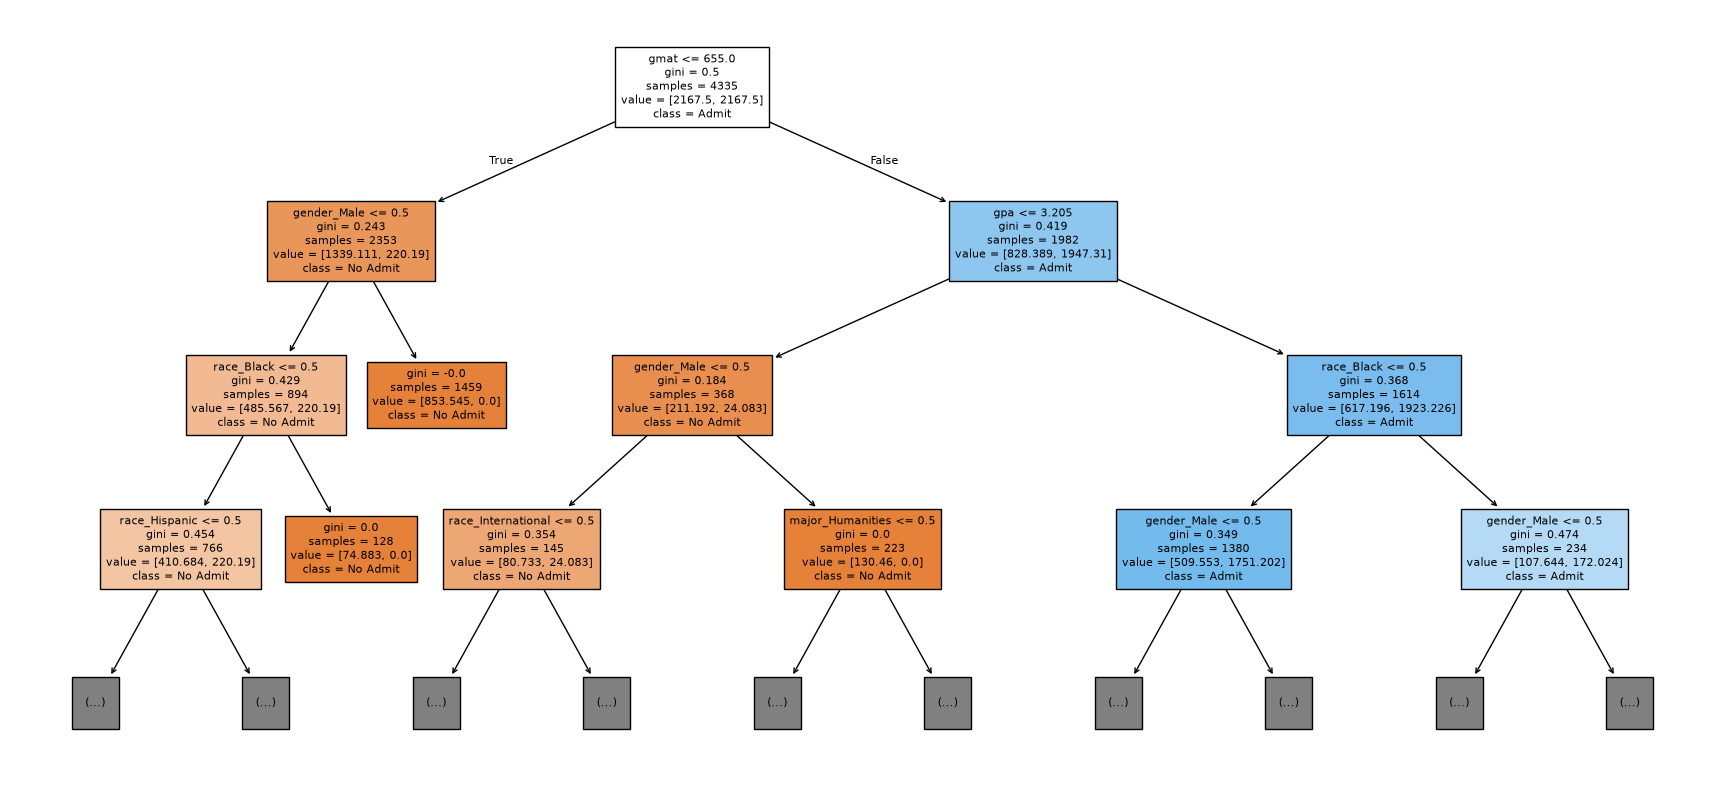

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(tree, feature_names=X_train.columns, class_names=['No Admit', 'Admit'],
          filled=True, max_depth=3, fontsize=8)
plt.show()

## Variable importance

In [23]:
pd.DataFrame(dict(Feature=tree.feature_names_in_, Value=tree.feature_importances_))\
  .sort_values(by='Value', ascending=False)

,Feature,Value
1,gmat,0.612255
0,gpa,0.200086
4,gender_Male,0.090129
7,race_Black,0.027610
8,race_Hispanic,0.020072
2,work_exp,0.011393
19,work_industry_Nonprofit/Gov,0.007320
9,race_International,0.007238
24,work_industry_Technology,0.005069
3,international,0.004371


## Prediction

In [24]:
y_pred_class = tree.predict(X_test)
y_pred_prob = tree.predict_proba(X_test)
y_pred_prob[:10, :]

array([[0.12525629, 0.87474371],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.31675365, 0.68324635],
       [0.87717553, 0.12282447],
       [0.49653486, 0.50346514],
       [0.49653486, 0.50346514],
       [1.        , 0.        ],
       [1.        , 0.        ]])

## Confusion matrix and classification report

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

confusion_matrix(y_true=y_test, y_pred=y_pred_class)

array([[1119,  470],
       [  28,  242]])

In [26]:
print(classification_report(y_true=y_test, y_pred=y_pred_class))

              precision    recall  f1-score   support

           0       0.98      0.70      0.82      1589
           1       0.34      0.90      0.49       270

    accuracy                           0.73      1859
   macro avg       0.66      0.80      0.66      1859
weighted avg       0.88      0.73      0.77      1859



## AUC ROC analysis

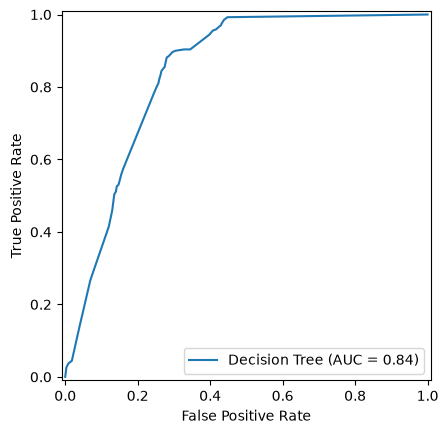

0.8385415938279375

In [27]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob[:, 1])
roc_auc_tree = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_tree, name='Decision Tree')
display.plot()
plt.show()
roc_auc_tree

# 4. Modeling - Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(min_samples_leaf=20, max_depth=8,
                             class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [29]:
pd.DataFrame(dict(Feature=rf.feature_names_in_, Value=rf.feature_importances_))\
  .sort_values(by='Value', ascending=False)

,Feature,Value
1,gmat,0.543656
0,gpa,0.299339
4,gender_Male,0.067944
7,race_Black,0.024378
8,race_Hispanic,0.011007
2,work_exp,0.007433
3,international,0.006795
9,race_International,0.005359
21,work_industry_PE/VC,0.004026
19,work_industry_Nonprofit/Gov,0.003916


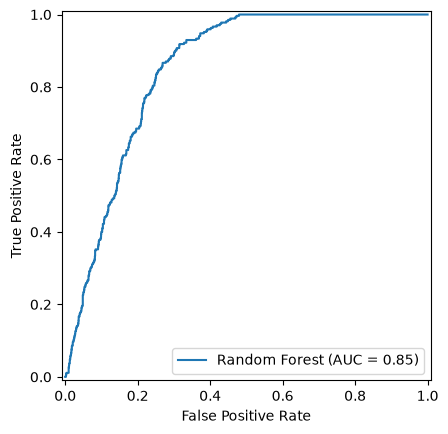

0.849129431508286

In [30]:
y_res = rf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:, 1])
roc_auc_rf = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_rf, name='Random Forest')
display.plot()
plt.show()
roc_auc_rf

In [31]:
y_pred_class = rf.predict(X_test)
print(confusion_matrix(y_true=y_test, y_pred=y_pred_class))
print(classification_report(y_true=y_test, y_pred=y_pred_class))

[[1111  478]
 [  28  242]]
              precision    recall  f1-score   support

           0       0.98      0.70      0.81      1589
           1       0.34      0.90      0.49       270

    accuracy                           0.73      1859
   macro avg       0.66      0.80      0.65      1859
weighted avg       0.88      0.73      0.77      1859



# 5. Modeling - Gradient Boosting

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(min_samples_leaf=20, n_estimators=200, random_state=42)
gbc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [33]:
pd.DataFrame(dict(Feature=gbc.feature_names_in_, Value=gbc.feature_importances_))\
  .sort_values(by='Value', ascending=False)

,Feature,Value
1,gmat,0.509502
0,gpa,0.287121
4,gender_Male,0.054319
7,race_Black,0.030565
2,work_exp,0.020023
8,race_Hispanic,0.018805
19,work_industry_Nonprofit/Gov,0.010978
17,work_industry_Investment Management,0.010958
14,work_industry_Financial Services,0.009006
11,race_White,0.007430


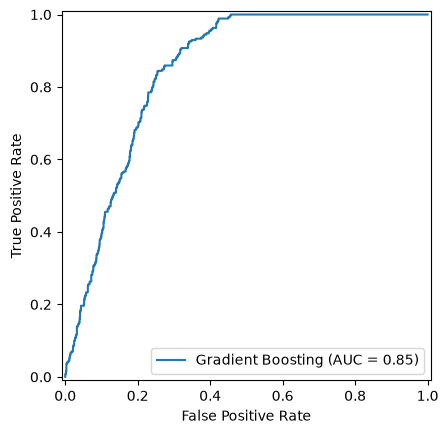

0.8455457660303475

In [34]:
y_res = gbc.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:, 1])
roc_auc_gbc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_gbc, name='Gradient Boosting')
display.plot()
plt.show()
roc_auc_gbc

In [35]:
y_pred_class = gbc.predict(X_test)
print(confusion_matrix(y_true=y_test, y_pred=y_pred_class))
print(classification_report(y_true=y_test, y_pred=y_pred_class))

[[1531   58]
 [ 231   39]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1589
           1       0.40      0.14      0.21       270

    accuracy                           0.84      1859
   macro avg       0.64      0.55      0.56      1859
weighted avg       0.80      0.84      0.81      1859



# 6. Model comparison

`GradientBoostingClassifier` has no `class_weight` option, so - unlike the tree and random forest -
it is not rebalanced for the minority (Admit) class. This trades away recall on admitted
applicants for higher overall accuracy, which shows up clearly below.

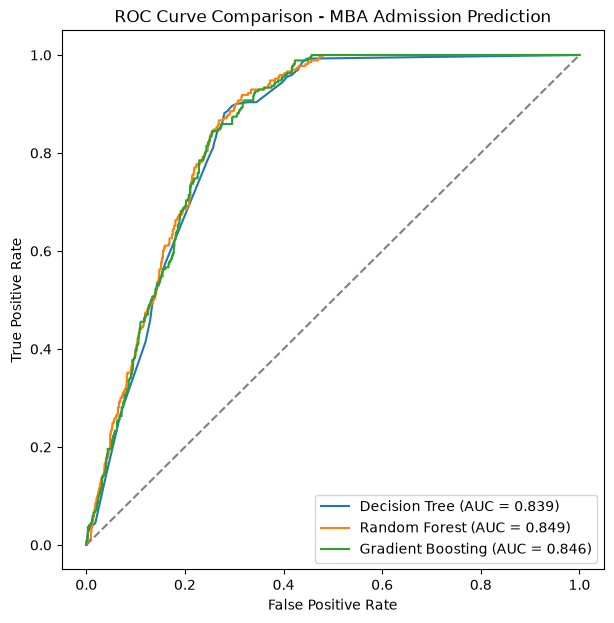

In [36]:
fpr_t, tpr_t, _ = roc_curve(y_test, tree.predict_proba(X_test)[:, 1])
fpr_r, tpr_r, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
fpr_g, tpr_g, _ = roc_curve(y_test, gbc.predict_proba(X_test)[:, 1])

plt.figure(figsize=(7, 7))
plt.plot(fpr_t, tpr_t, label=f'Decision Tree (AUC = {roc_auc_tree:.3f})')
plt.plot(fpr_r, tpr_r, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_g, tpr_g, label=f'Gradient Boosting (AUC = {roc_auc_gbc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - MBA Admission Prediction')
plt.legend()
plt.show()

In [37]:
pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'AUC': [roc_auc_tree, roc_auc_rf, roc_auc_gbc]
}).sort_values(by='AUC', ascending=False)

,Model,AUC
1,Random Forest,0.849129
2,Gradient Boosting,0.845546
0,Decision Tree,0.838542


# 7. สรุปผล

- **โจทย์**: ทำนายว่าผู้สมัคร MBA จะได้รับ Admit หรือไม่ จากข้อมูล `MBA.csv` (6,194 คน)
- **ตัวแปรเป้าหมาย**: `is_admit` = 1 ถ้า `admission == 'Admit'`, นอกนั้น (Waitlist หรือไม่มีข้อเสนอ) = 0
  ซึ่งพบว่ามีสัดส่วนผู้ได้รับ Admit ราว 14.5% เท่านั้น (ข้อมูลไม่สมดุล)
- **การเตรียมข้อมูล**: เติมค่า `race` ที่หายไปด้วย `'International'` (หายไปเฉพาะผู้สมัครต่างชาติ),
  แปลงตัวแปรเชิงหมวดหมู่ (gender, major, race, work_industry) ด้วย one-hot encoding,
  แบ่งข้อมูล train/test แบบ stratify ตามสัดส่วนของ target
- **โมเดลที่ใช้**: Decision Tree, Random Forest (ทั้งสองใช้ `class_weight='balanced'` เพื่อแก้ปัญหาข้อมูลไม่สมดุล)
  และ Gradient Boosting (ไม่มีตัวเลือก `class_weight`)

| โมเดล | AUC |
|---|---|
| Random Forest | 0.849 |
| Gradient Boosting | 0.846 |
| Decision Tree | 0.839 |

**สรุป**: ทั้งสามโมเดลให้ผลใกล้เคียงกันมาก (AUC ~0.84-0.85) โดย **Random Forest** ทำได้ดีที่สุดเล็กน้อย
ส่วน **Gradient Boosting** แม้ AUC จะสูงเป็นอันดับสอง แต่เนื่องจากไม่ได้ปรับ `class_weight`
จึงมี recall ของกลุ่ม Admit ต่ำกว่ามาก (ทำนายพลาดผู้ที่ควรได้ Admit บ่อยกว่า) —
หากเป้าหมายคือไม่พลาดผู้สมัครที่ควรได้รับ Admit ควรเลือก Decision Tree หรือ Random Forest ที่ balance คลาสแล้ว
